# Annual thirstwave metrics (growing season only, event-based)

## Import libraries and define helper functions

In [1]:
import scienceplots
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '../') # Trick to import code from parent library
import cmip6_archive as ca

In [2]:
def global_weighted_mean(da: xr.DataArray):
    "Calculates global spatial mean using cosine weighting."
    weights = np.cos(np.deg2rad(da.lat))   
    return da.weighted(weights).mean(("lon", "lat"))

## Load thirstwave metrics during the growing season

In [ ]:
models = ca.MODELS
experiments = ca.EXPERIMENTS
combinations = [(model, exp) for model in models for exp in experiments]

# Load back all results from the .nc files
all_results = {model: {} for model in ca.MODELS}
n_loaded = 0
for (model, exp) in combinations:
    ds = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp=exp)
    if ds is not None:
        all_results[model][exp] = ds
        n_loaded += 1

print(f"✅ Loaded data from {n_loaded} model x experiment combinations")

✅ Loaded data from 40 model x experiment combinations


## Compute global mean intensity, frequency and duration

In [40]:
intensity_all = {exp: {} for exp in experiments}
frequency_all = {exp: {} for exp in experiments}
duration_all = {exp: {} for exp in experiments}
rad_frac_all = {exp: {} for exp in experiments}
for exp in experiments:
    for model in models:
        try:
            ds = all_results.get(model).get(exp)
            land_area_fraction = ca.LAND_MASKS_ARCHIVE.open(model=model, exp='piControl')['sftlf']
            if ds is None or land_area_fraction is None:
                print(f"[{model} / {exp}] ERROR loading")
                continue
            
        except Exception as e:
            print(f"[{model} / {exp}] ERROR: {e}")

        # Mask out grid cells with < 5% land
        ds_masked = ds.where(land_area_fraction.values >= 5)

        # Calculate global mean intensity, frequency and duraton and store
        intensity_all[exp][model] = global_weighted_mean(ds_masked.intensity).compute()
        frequency_all[exp][model] = global_weighted_mean(ds_masked.event_count).compute()
        duration_all[exp][model] = global_weighted_mean(ds_masked.mean_duration).compute()
        rad_frac_all[exp][model] = global_weighted_mean(ds_masked.rad_frac_tw).compute()

    ints = [ds_masked for m, ds_masked in intensity_all[exp].items() if ds_masked is not np.nan]
    freqs = [ds_masked for m, ds_masked in frequency_all[exp].items() if ds_masked is not np.nan]
    durs = [ds_masked for m, ds_masked in duration_all[exp].items() if ds_masked is not np.nan]
    rad_fracs = [ds_masked for m, ds_masked in rad_frac_all[exp].items() if ds_masked is not np.nan]

    # Find multi-model mean of frequency, intensity and duration
    intensity_all[exp]["mean"] = xr.concat(ints, dim="model").mean(dim="model")
    frequency_all[exp]["mean"] = xr.concat(freqs, dim="model").mean(dim="model")
    duration_all[exp]["mean"] = xr.concat(durs, dim="model").mean(dim="model")
    rad_frac_all[exp]["mean"] = xr.concat(rad_fracs, dim="model").mean(dim="model")

    # Inter-model spread: standard deviation across models
    intensity_all[exp]["std"] = xr.concat(ints, dim="model").std(dim="model")
    frequency_all[exp]["std"] = xr.concat(freqs, dim="model").std(dim="model")
    duration_all[exp]["std"] = xr.concat(durs, dim="model").std(dim="model")
    rad_frac_all[exp]["std"] = xr.concat(rad_fracs, dim="model").std(dim="model")

## Plot

In [30]:
# Line styling for each experiment (color + linewidth), shared across all panels
EXPERIMENT_STYLE = {
    "historical": {"color": "#c4c4c4", "linewidth": 0.3, "zorder": 0, "alpha": 0.3},
    "ssp126": {"color": "#f4bbba", "linewidth": 0.3, "zorder": 1, "alpha": 0.3},
    "ssp245": {"color": "#ed8e8c", "linewidth": 0.3, "zorder": 2, "alpha": 0.3},
    "ssp370": {"color": "#cb4d4e", "linewidth": 0.3, "zorder": 3, "alpha": 0.3},
    "ssp585": {"color": "#a4181c", "linewidth": 0.3, "zorder": 4, "alpha": 0.3},
}

# Year at which the historical experiment ends and the SSPs begin
TRANSITION_YEAR = 2014

# Fixed x-axis range for the combined figure
XLIM = (1980, 2100)


	Saved figure to /work10/archive/CMIP6/CMIP-SSPs/code/daily-ET0/figures/annual_thirstwave_metrics_growing_season_masked.png


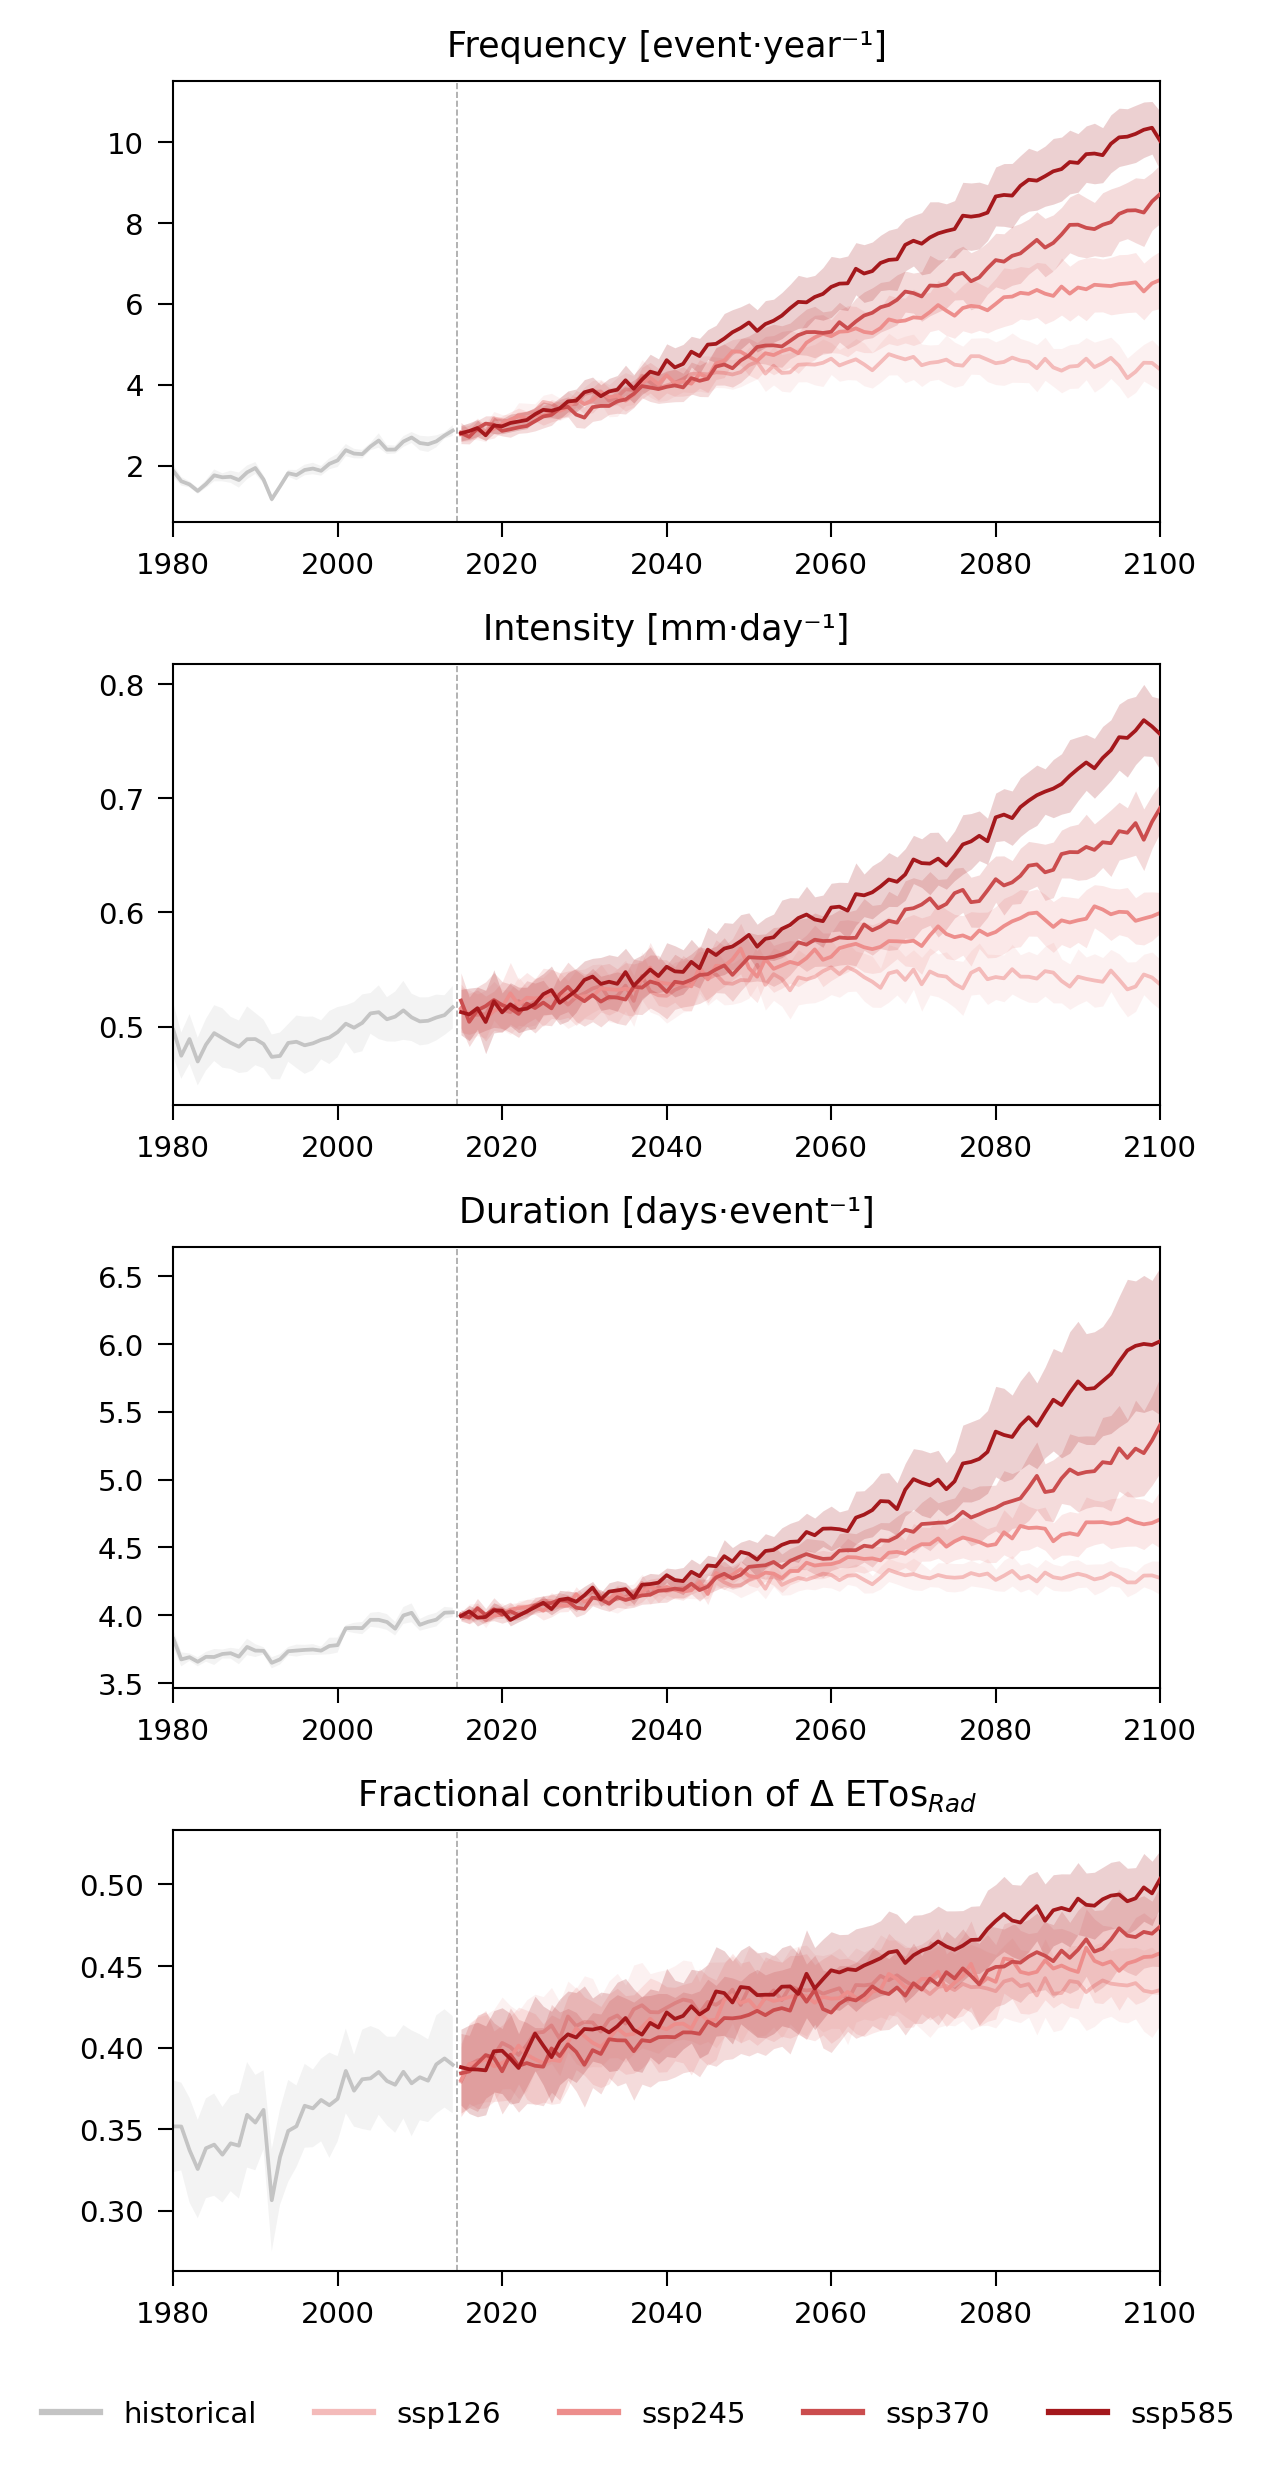

In [45]:
# Style adjustments (Nature style)
plt.style.use('nature')
mm = 1/25.4  # mm to inches
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(100*mm, 200*mm))

plot_params = { "figure.dpi": "300",
               "font.size": 7,
               "axes.labelsize": 5,
               "figure.titlesize": 7,
               "xtick.major.width": 0.5,
               "ytick.major.width": 0.5,
               }
plt.rcParams.update(plot_params)

for exp in experiments:
    style = EXPERIMENT_STYLE[exp]

    # Plot mean of the 8 models with a thicker line
    frequency_all[exp]["mean"].plot(ax=axes[0], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"], alpha=1) 
    intensity_all[exp]["mean"].plot(ax=axes[1], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"], alpha=1)
    duration_all[exp]["mean"].plot(ax=axes[2], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"], alpha=1)
    rad_frac_all[exp]["mean"].plot(ax=axes[3], color=style["color"], linewidth=style["linewidth"]*3, zorder=style["zorder"], alpha=1)

    # Shading represents inter-model spread (mean +- 0.5 std)
    x = intensity_all[exp]["mean"].year

    frequency_upper = frequency_all[exp]["mean"] + frequency_all[exp]["std"]*0.5
    frequency_lower = frequency_all[exp]["mean"] - frequency_all[exp]["std"]*0.5
    axes[0].fill_between(x, frequency_lower.values, frequency_upper.values, color=style["color"], alpha=0.2, linewidth=0)

    intensity_upper = intensity_all[exp]["mean"] + intensity_all[exp]["std"]*0.5
    intensity_lower = intensity_all[exp]["mean"] - intensity_all[exp]["std"]*0.5
    axes[1].fill_between(x, intensity_lower.values, intensity_upper.values, color=style["color"], alpha=0.2, linewidth=0)

    duration_upper = duration_all[exp]["mean"] + duration_all[exp]["std"]*0.5
    duration_lower = duration_all[exp]["mean"] - duration_all[exp]["std"]*0.5
    axes[2].fill_between(x, duration_lower.values, duration_upper.values, color=style["color"], alpha=0.2, linewidth=0)

    rad_frac_upper = rad_frac_all[exp]["mean"] + rad_frac_all[exp]["std"]*0.5
    rad_frac_lower = rad_frac_all[exp]["mean"] - rad_frac_all[exp]["std"]*0.5
    axes[3].fill_between(x, rad_frac_lower.values, rad_frac_upper.values, color=style["color"], alpha=0.2, linewidth=0)


for ax in axes:
    ax.axvline(TRANSITION_YEAR+0.5, color="grey", linestyle="--", linewidth=0.4, alpha=0.7) # Dashed grey vertical line marking the end of the historical exp / start of the SSPs
    ax.set_xlim(*XLIM) # X axis from 1980 to 2100
    ax.set_xlabel('')
    ax.set_ylabel('')

axes[0].set_title("Frequency [event·year⁻¹]")
axes[1].set_title("Intensity [mm·day⁻¹]")
axes[2].set_title("Duration [days·event⁻¹]")
axes[3].set_title(r"Fractional contribution of $\Delta$ ETos$_{Rad}$")

# Shared legend for the whole figure
legend_handles = [
    Line2D([0], [0], color=style["color"], linewidth=1.5, alpha=1, label=exp)
    for exp, style in EXPERIMENT_STYLE.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.04), frameon=False)

fig.tight_layout()
#fig.subplots_adjust(wspace=0.3, hspace=0.4)

# Export to png
outdir = Path(".")
outdir.mkdir(exist_ok=True)
outpath = outdir / f"annual_thirstwave_metrics_growing_season_masked.png"
fig.savefig(outpath, dpi=300, bbox_inches="tight")
print(f"\n\tSaved figure to {outpath.resolve()}")